#Install Library

In [1]:
!pip install sastrawi
!pip install transformers torch
!pip install feedparser pandas
!pip install google-play-scraper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 2.3 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=47554632bbc29b0379203abd1aefd6541cb4a5e8bce7b2ae3bca7292238eafc0
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00


#Import Library

In [2]:
import pandas as pd
from google_play_scraper import reviews, Sort

import nltk
from nltk.corpus import stopwords as nltk_stopwords

from transformers import pipeline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

#Google Playstore

In [3]:
result, continuation_token = reviews(
    'com.apps.MyXL',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=5000)
df_playstore = pd.DataFrame(result)

In [4]:
df_playstore

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c5c65f79-a76b-420f-9d82-1f41fdeb2d0a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya sudah menggunakan XL 10 thun lebih, tolon...",1,0,None,2026-07-08 03:23:53,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-07-08 05:00:25,None
1,5c8ed04c-a709-4e0c-a9e1-3495ef81a683,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"lemot banget ih, gangguan terus",3,0,9.3.0,2026-07-08 03:21:43,"Hi Kak, Maya dengan senang membantu kendala Ka...",2026-07-08 05:00:27,9.3.0
2,e42bf15a-16b2-4f9a-9860-028ad8de17ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,regristrasi kartu selalu gagal xl sampah,1,0,None,2026-07-08 03:16:36,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-07-08 05:00:30,None
3,4adfd306-bd85-465a-8df5-9037eead85c0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya sangat suka,5,0,None,2026-07-08 03:15:03,"Hi Kak, terima kasih sudah memberikan penilaia...",2026-07-08 05:00:32,None
4,c5c275bf-d249-454d-926b-c1b6065dcf31,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sinyal ga jelas jaringan 5g tercepat di Indone...,1,0,None,2026-07-08 03:10:47,"Hi Kak, mohon maaf ya atas ketidaknyamanan yan...",2026-07-08 05:00:35,None
...,...,...,...,...,...,...,...,...,...,...,...
4995,d39fecfc-dcb1-4abb-bac3-eaa6ce690a1c,Juika Naura,https://play-lh.googleusercontent.com/a/ACg8oc...,ini gimana login nya eror terus tolong,3,0,9.2.0,2026-06-05 01:01:48,"Hi Kak, mohon maaf atas kendala yang Kakak ala...",2026-06-05 01:01:08,9.2.0
4996,624148ff-9bd1-4cb9-8baa-78e499086aba,Sales Owanglass,https://play-lh.googleusercontent.com/a-/ALV-U...,lelet banget,3,0,9.2.0,2026-06-05 01:01:06,None,NaT,9.2.0
4997,9747f3f8-8863-4a6d-9069-04834caa15eb,Salma Salsabila,https://play-lh.googleusercontent.com/a-/ALV-U...,"apk nya suka lemot bikin emosi, padahal buat b...",3,0,None,2026-06-05 01:00:14,"Hi Kak, Maya akan senang membantu menyelesaika...",2026-06-05 01:00:09,None
4998,c1f059e1-8f29-41ea-b11f-997bd0e7f179,yuseffendi travo,https://play-lh.googleusercontent.com/a-/ALV-U...,kenapa sih aplikasinya sering trouble.. bikin ...,2,0,9.2.0,2026-06-05 01:00:08,None,NaT,9.2.0


In [5]:
# df_playstore.head(25)

In [6]:
# df_playstore.shape

In [7]:
# df_playstore.columns

In [8]:
# import pandas as pd

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.width', None)
# pd.set_option('display.expand_frame_repr', False)

# display(df_playstore)

#Sentiment Analysis

##Read Data

In [9]:
df_playstore.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c5c65f79-a76b-420f-9d82-1f41fdeb2d0a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya sudah menggunakan XL 10 thun lebih, tolon...",1,0,None,2026-07-08 03:23:53,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-07-08 05:00:25,None
1,5c8ed04c-a709-4e0c-a9e1-3495ef81a683,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"lemot banget ih, gangguan terus",3,0,9.3.0,2026-07-08 03:21:43,"Hi Kak, Maya dengan senang membantu kendala Ka...",2026-07-08 05:00:27,9.3.0
2,e42bf15a-16b2-4f9a-9860-028ad8de17ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,regristrasi kartu selalu gagal xl sampah,1,0,None,2026-07-08 03:16:36,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-07-08 05:00:30,None
3,4adfd306-bd85-465a-8df5-9037eead85c0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya sangat suka,5,0,None,2026-07-08 03:15:03,"Hi Kak, terima kasih sudah memberikan penilaia...",2026-07-08 05:00:32,None
4,c5c275bf-d249-454d-926b-c1b6065dcf31,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sinyal ga jelas jaringan 5g tercepat di Indone...,1,0,None,2026-07-08 03:10:47,"Hi Kak, mohon maaf ya atas ketidaknyamanan yan...",2026-07-08 05:00:35,None


In [10]:
df = df_playstore[['content']].copy()

#Data Understanding (EDA Awal)

##Cek Missing Value & Duplicate

In [11]:
df.isnull().sum()

,0
content,0


In [12]:
df.duplicated().sum()

np.int64(206)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

##Visualisasi

###Distribusi Rating

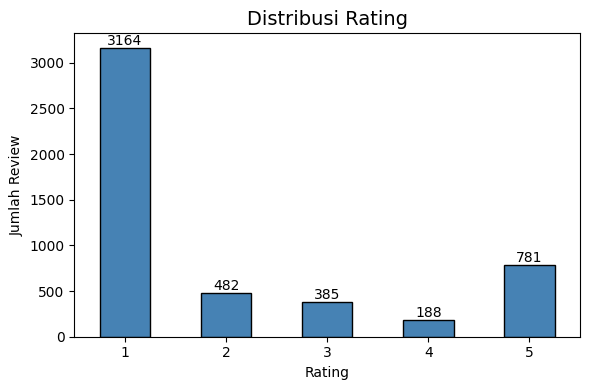

In [15]:
rating = df_playstore['score'].value_counts().sort_index()

plt.figure(figsize=(6,4))
ax = rating.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Distribusi Rating', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)

# Tambahkan jumlah di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

###Distribusi Panjang Review

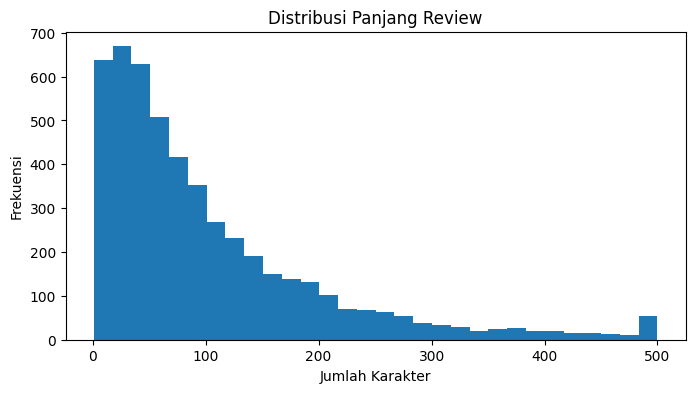

In [16]:
df_playstore['review_length'] = df_playstore['content'].str.len()

plt.figure(figsize=(8,4))
plt.hist(df_playstore['review_length'], bins=30)
plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

###Top 10 Review Terbanyak

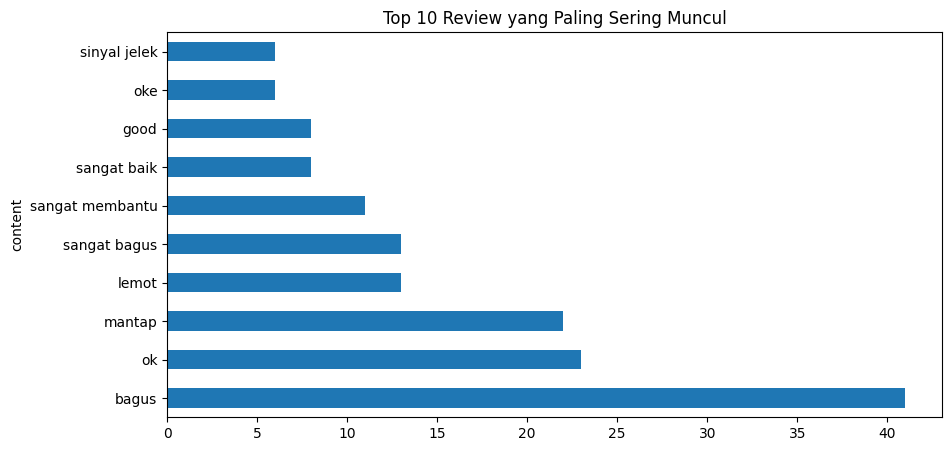

In [17]:
top_review = df_playstore['content'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_review.plot(kind='barh')
plt.title('Top 10 Review yang Paling Sering Muncul')
plt.show()

#Data Preprocessing

In [18]:
def cleaning(text):
    text = str(text)

    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Hapus mention
    text = re.sub(r'@\w+', ' ', text)

    # Hapus hashtag, tapi pertahankan katanya
    text = re.sub(r'#(\w+)', r'\1', text)

    # Ganti titik dan underscore menjadi spasi
    text = text.replace('.', ' ')
    text = text.replace('_', ' ')

    # Hapus angka
    text = re.sub(r'\d+', ' ', text)

    # Hapus emoji
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        " ",
        text,
        flags=re.UNICODE
    )

    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Sisakan huruf dan spasi
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaning'] = df['content'].apply(cleaning)

In [19]:
df.head()

,content,cleaning
0,"saya sudah menggunakan XL 10 thun lebih, tolon...",saya sudah menggunakan XL thun lebih tolong si...
1,"lemot banget ih, gangguan terus",lemot banget ih gangguan terus
2,regristrasi kartu selalu gagal xl sampah,regristrasi kartu selalu gagal xl sampah
3,Saya sangat suka,Saya sangat suka
4,sinyal ga jelas jaringan 5g tercepat di Indone...,sinyal ga jelas jaringan g tercepat di Indones...


In [20]:
df.tail()

,content,cleaning
4994,mau beli kuota aja susah. gangguan lah apalah ...,mau beli kuota aja susah gangguan lah apalah pagi
4995,ini gimana login nya eror terus tolong,ini gimana login nya eror terus tolong
4997,"apk nya suka lemot bikin emosi, padahal buat b...",apk nya suka lemot bikin emosi padahal buat bu...
4998,kenapa sih aplikasinya sering trouble.. bikin ...,kenapa sih aplikasinya sering trouble bikin gk...
4999,selalu gangguan wktu buka aplikasi ga jelas,selalu gangguan wktu buka aplikasi ga jelas


##Case Folding

In [21]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
      return text.lower()
df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(10)

,content,cleaning,case_folding
0,"saya sudah menggunakan XL 10 thun lebih, tolon...",saya sudah menggunakan XL thun lebih tolong si...,saya sudah menggunakan xl thun lebih tolong si...
1,"lemot banget ih, gangguan terus",lemot banget ih gangguan terus,lemot banget ih gangguan terus
2,regristrasi kartu selalu gagal xl sampah,regristrasi kartu selalu gagal xl sampah,regristrasi kartu selalu gagal xl sampah
3,Saya sangat suka,Saya sangat suka,saya sangat suka
4,sinyal ga jelas jaringan 5g tercepat di Indone...,sinyal ga jelas jaringan g tercepat di Indones...,sinyal ga jelas jaringan g tercepat di indones...
5,"jaringan nya sering ilang , sinyal buruk !",jaringan nya sering ilang sinyal buruk,jaringan nya sering ilang sinyal buruk
6,sudah baik,sudah baik,sudah baik
7,CHAT CS UDAH DAPAT GILIRAN ANTRIAN EH MASIH JU...,CHAT CS UDAH DAPAT GILIRAN ANTRIAN EH MASIH JU...,chat cs udah dapat giliran antrian eh masih ju...
8,KUALITAS BURUK,KUALITAS BURUK,kualitas buruk
9,Saya harap perbanyak tambahan benefit yang bis...,Saya harap perbanyak tambahan benefit yang bis...,saya harap perbanyak tambahan benefit yang bis...


##Tokenize

In [22]:
def tokenize(text):
    tokens = text.split()
    return tokens
df['tokenize'] = df['case_folding'].apply(tokenize)
df.head(25)

,content,cleaning,case_folding,tokenize
0,"saya sudah menggunakan XL 10 thun lebih, tolon...",saya sudah menggunakan XL thun lebih tolong si...,saya sudah menggunakan xl thun lebih tolong si...,"[saya, sudah, menggunakan, xl, thun, lebih, to..."
1,"lemot banget ih, gangguan terus",lemot banget ih gangguan terus,lemot banget ih gangguan terus,"[lemot, banget, ih, gangguan, terus]"
2,regristrasi kartu selalu gagal xl sampah,regristrasi kartu selalu gagal xl sampah,regristrasi kartu selalu gagal xl sampah,"[regristrasi, kartu, selalu, gagal, xl, sampah]"
3,Saya sangat suka,Saya sangat suka,saya sangat suka,"[saya, sangat, suka]"
4,sinyal ga jelas jaringan 5g tercepat di Indone...,sinyal ga jelas jaringan g tercepat di Indones...,sinyal ga jelas jaringan g tercepat di indones...,"[sinyal, ga, jelas, jaringan, g, tercepat, di,..."
5,"jaringan nya sering ilang , sinyal buruk !",jaringan nya sering ilang sinyal buruk,jaringan nya sering ilang sinyal buruk,"[jaringan, nya, sering, ilang, sinyal, buruk]"
6,sudah baik,sudah baik,sudah baik,"[sudah, baik]"
7,CHAT CS UDAH DAPAT GILIRAN ANTRIAN EH MASIH JU...,CHAT CS UDAH DAPAT GILIRAN ANTRIAN EH MASIH JU...,chat cs udah dapat giliran antrian eh masih ju...,"[chat, cs, udah, dapat, giliran, antrian, eh, ..."
8,KUALITAS BURUK,KUALITAS BURUK,kualitas buruk,"[kualitas, buruk]"
9,Saya harap perbanyak tambahan benefit yang bis...,Saya harap perbanyak tambahan benefit yang bis...,saya harap perbanyak tambahan benefit yang bis...,"[saya, harap, perbanyak, tambahan, benefit, ya..."


In [23]:
df.tail(25)

,content,cleaning,case_folding,tokenize
4974,plisss jangan lemot ya apk mohon kerjasamanya ...,plisss jangan lemot ya apk mohon kerjasamanya ...,plisss jangan lemot ya apk mohon kerjasamanya ...,"[plisss, jangan, lemot, ya, apk, mohon, kerjas..."
4975,mau buka myxl aja susah gangguan gangguan teru...,mau buka myxl aja susah gangguan gangguan teru...,mau buka myxl aja susah gangguan gangguan teru...,"[mau, buka, myxl, aja, susah, gangguan, ganggu..."
4976,setelah di update gg bisa di gunakan haduuuh p...,setelah di update gg bisa di gunakan haduuuh p...,setelah di update gg bisa di gunakan haduuuh p...,"[setelah, di, update, gg, bisa, di, gunakan, h..."
4977,ganguan trus eror terus jelek katanya 5g terce...,ganguan trus eror terus jelek katanya g tercep...,ganguan trus eror terus jelek katanya g tercep...,"[ganguan, trus, eror, terus, jelek, katanya, g..."
4978,"makin kesini signal XL bapuk sering ilang""an",makin kesini signal XL bapuk sering ilangan,makin kesini signal xl bapuk sering ilangan,"[makin, kesini, signal, xl, bapuk, sering, ila..."
4979,kuota nya mahal,kuota nya mahal,kuota nya mahal,"[kuota, nya, mahal]"
4980,"aplikasi jelek, sinyal jelek, udah bayar mahal...",aplikasi jelek sinyal jelek udah bayar mahal s...,aplikasi jelek sinyal jelek udah bayar mahal s...,"[aplikasi, jelek, sinyal, jelek, udah, bayar, ..."
4981,udh setahunan. pke wifi XL... lancar jaya... t...,udh setahunan pke wifi XL lancar jaya tks xl,udh setahunan pke wifi xl lancar jaya tks xl,"[udh, setahunan, pke, wifi, xl, lancar, jaya, ..."
4982,aplikasi yg sangat buruk..masuk login aja sang...,aplikasi yg sangat buruk masuk login aja sanga...,aplikasi yg sangat buruk masuk login aja sanga...,"[aplikasi, yg, sangat, buruk, masuk, login, aj..."
4983,ga bisa di lihat kouta nya kek ada layar putih,ga bisa di lihat kouta nya kek ada layar putih,ga bisa di lihat kouta nya kek ada layar putih,"[ga, bisa, di, lihat, kouta, nya, kek, ada, la..."


##Normalize Slang

In [24]:
slang_dict = {
    'yg':'yang',
    'abiss':'habis',
    'bangett':'banget',
    'ad':'ada',
    'adaaa':'ada',
    'adaaaaaa':'ada',
    'ajaa':'aja',
    'lgy':'lg',
    'lagg':'lag',
    'ud':'udah',
    'pake':'pakai',
    'bgd':'banget',
    'jaringanx':'jaringan',
    'lbh':'lebih',
    'D':'di',
    'tpi':'tapi',
    'tp':'tapi',
    'baguss':'bagus',
    'utk':'untuk',
     'gk':'tidak',
    'gak':'tidak',
    'ga':'tidak',
    'nggak':'tidak',
    'ngga':'tidak',
    'enggak':'tidak',
    'tdk':'tidak',
    'kaga':'tidak',
    'bgd':'banget',
    'udh':'sudah',
    'udah':'sudah',
    'jg':'juga',
    'bgtu':'begitu',
    'abdet':'update',
    'msh':'masih',
    'ilang':'hilang',
    'lg':'lagi',
    'lgy':'lagi',
    'jdi':'jadi',
    'bgt':'banget',
    'bngt':'banget',
    'bnget':'banget',
    'dri':'dari',
    'pake':'pakai',
    'enang':'emang',
    'eror':'error',
    'ilang':'hilang',
    'dg':'dengan',
    'dgn':'dengan',
    'bgn' :'bangun',
    'utk':'untuk',
    'udh':'sudah',
    'udah':'sudah',
    'blm':'belum',
    'sm':'sama',
    'krn':'karena',
    'dr':'dari',
    'trs':'terus',
    'lu' : 'kamu',
    'loe' : 'kamu',
    'dpt':'dapat',
    'dapet':'dapat',
    'bkn':'bukan',
    'jd':'jadi',
    'jdi':'jadi',
    'lalot':'lambat',
    'jlek':'jelek',
    'aktifa':'aktif',
    'skrng':'sekarang',
    'manisss':'manis',
    'awallll':'awal',
    'smpe':'sampai',
    'jringan':'jaringan',
    'ngeleggg':'lag',
    'bettttt':'banget',
    'kalaw':'kalau',
    'pitur':'fitur',
    'bwt':'buat',
    'byr':'bayar',
    'pke':'pakai',
    'pkai':'pakai',
    'org':'orang',
    'ank':'anak',
    'ortu':'orang tua',
    'mrk':'mereka',
    'sy':'saya',
    'sya':'saya',
    'gw':'saya',
    'gua':'saya',
    'gue':'saya',
    'aq':'aku',
    'bgt':'banget',
    'bngt':'banget',
    'bnget':'banget',
    'jgn':'jangan',
    'jngn':'jangan',
    'hr':'hari',
    'hri':'hari',
    'thn':'tahun',
    'bln':'bulan',
    'byk':'banyak',
    'bnyk':'banyak',
    'sdkt':'sedikit',
    'mnrt':'menurut',
    'pdhl':'padahal',
    'klu':'kalau',
    'kalo':'kalau',
    'klo':'kalau',
    'kl':'kalau',
    'tp':'tapi',
    'tpi':'tapi',
    'bs':'bisa',
    'bsa':'bisa',
    'aja':'saja',
    'doang':'saja',
    'smoga':'semoga',
    'moga':'semoga',
    'kyk':'seperti',
    'cm':'cuma',
    'cmn':'cuma',
     "yg":"yang",
    "gk":"tidak",
    "ga":"tidak",
    "nggak":"tidak",
    "tdk":"tidak",
    "bgt":"banget",
    "krn":"karena",
    "jd":"jadi",
    "pdhl":"padahal",
    "udah":"sudah",
    "sdh":"sudah",
}

def normalize_slang(tokens):

    return [
        slang_dict[word] if word in slang_dict else word
        for word in tokens
    ]

df['normalize'] = df['tokenize'].apply(normalize_slang)

In [25]:
df.head()

,content,cleaning,case_folding,tokenize,normalize
0,"saya sudah menggunakan XL 10 thun lebih, tolon...",saya sudah menggunakan XL thun lebih tolong si...,saya sudah menggunakan xl thun lebih tolong si...,"[saya, sudah, menggunakan, xl, thun, lebih, to...","[saya, sudah, menggunakan, xl, thun, lebih, to..."
1,"lemot banget ih, gangguan terus",lemot banget ih gangguan terus,lemot banget ih gangguan terus,"[lemot, banget, ih, gangguan, terus]","[lemot, banget, ih, gangguan, terus]"
2,regristrasi kartu selalu gagal xl sampah,regristrasi kartu selalu gagal xl sampah,regristrasi kartu selalu gagal xl sampah,"[regristrasi, kartu, selalu, gagal, xl, sampah]","[regristrasi, kartu, selalu, gagal, xl, sampah]"
3,Saya sangat suka,Saya sangat suka,saya sangat suka,"[saya, sangat, suka]","[saya, sangat, suka]"
4,sinyal ga jelas jaringan 5g tercepat di Indone...,sinyal ga jelas jaringan g tercepat di Indones...,sinyal ga jelas jaringan g tercepat di indones...,"[sinyal, ga, jelas, jaringan, g, tercepat, di,...","[sinyal, tidak, jelas, jaringan, g, tercepat, ..."


##Stopword Removal

In [26]:
nltk.download('stopwords', quiet=True)
stopword_id = set(nltk_stopwords.words('indonesian'))

custom_stopwords = {
    'yg','aja','nih','dong','btw','emang',
    'nya','ya','sih','min','admin','pa','lah','mah','kok'}

stopword_id.update(custom_stopwords)

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopword_id]
df['stopword'] = df['normalize'].apply(remove_stopwords)

In [27]:
df.head()

,content,cleaning,case_folding,tokenize,normalize,stopword
0,"saya sudah menggunakan XL 10 thun lebih, tolon...",saya sudah menggunakan XL thun lebih tolong si...,saya sudah menggunakan xl thun lebih tolong si...,"[saya, sudah, menggunakan, xl, thun, lebih, to...","[saya, sudah, menggunakan, xl, thun, lebih, to...","[xl, thun, tolong, sinyalnya, diperbaiki, pram..."
1,"lemot banget ih, gangguan terus",lemot banget ih gangguan terus,lemot banget ih gangguan terus,"[lemot, banget, ih, gangguan, terus]","[lemot, banget, ih, gangguan, terus]","[lemot, banget, ih, gangguan]"
2,regristrasi kartu selalu gagal xl sampah,regristrasi kartu selalu gagal xl sampah,regristrasi kartu selalu gagal xl sampah,"[regristrasi, kartu, selalu, gagal, xl, sampah]","[regristrasi, kartu, selalu, gagal, xl, sampah]","[regristrasi, kartu, gagal, xl, sampah]"
3,Saya sangat suka,Saya sangat suka,saya sangat suka,"[saya, sangat, suka]","[saya, sangat, suka]",[suka]
4,sinyal ga jelas jaringan 5g tercepat di Indone...,sinyal ga jelas jaringan g tercepat di Indones...,sinyal ga jelas jaringan g tercepat di indones...,"[sinyal, ga, jelas, jaringan, g, tercepat, di,...","[sinyal, tidak, jelas, jaringan, g, tercepat, ...","[sinyal, jaringan, g, tercepat, indonesia, anj..."


##Stemming

In [28]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stemming(tokens):
  kalimat = ' '.join(tokens)
  return stemmer.stem(kalimat)
df['stemming'] = df['stopword'].apply(stemming)

#Sentiment Labeling

In [29]:
classifier = pipeline(
    "sentiment-analysis",
    model = "w11wo/indonesian-roberta-base-sentiment-classifier")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
labels = []
scores = []

for text in df['stemming']:

    if pd.notnull(text):

        result = classifier(str(text))[0]

        labels.append(result['label'])
        scores.append(result['score'])

    else:

        labels.append('unknown')
        scores.append(0)

df['sentiment'] = labels
df['sentiment_score'] = scores

In [62]:
df[['stemming','sentiment']].head(20)

,stemming,sentiment
0,xl thun tolong sinyal baik prambanan,neutral
1,lot banget ih ganggu,negative
2,regristrasi kartu gagal xl sampah,negative
3,suka,negative
4,sinyal jaring g cepat indonesia anjir jarang p...,neutral
5,jaring hilang sinyal buruk,negative
6,,neutral
7,chat cs gilir antri eh nunggu balas tunggu seb...,negative
8,kualitas buruk,negative
9,harap banyak tambah benefit tukar poin xl apk ...,neutral


In [ ]:
df['sentiment'].value_counts()

#EDA

##1. Distribusi Sentimen

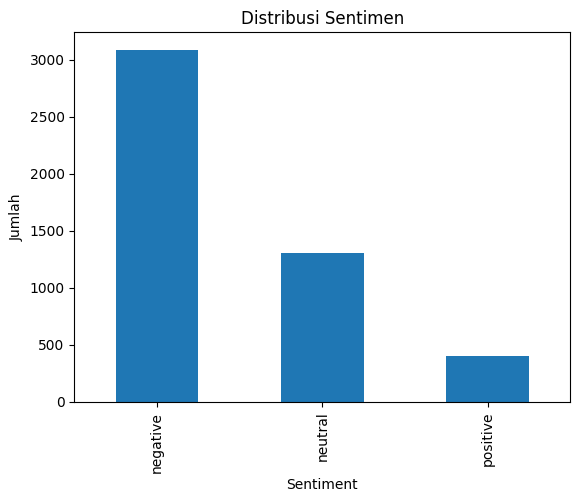

In [33]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(
    kind='bar',
    xlabel='Sentiment',
    ylabel='Jumlah',
    title='Distribusi Sentimen'
)

plt.show()

<Axes: ylabel='count'>

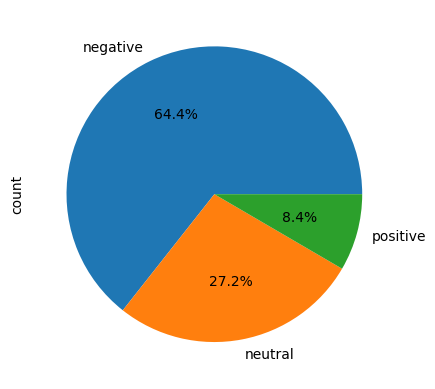

In [34]:
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

##2. WordCloud Positive

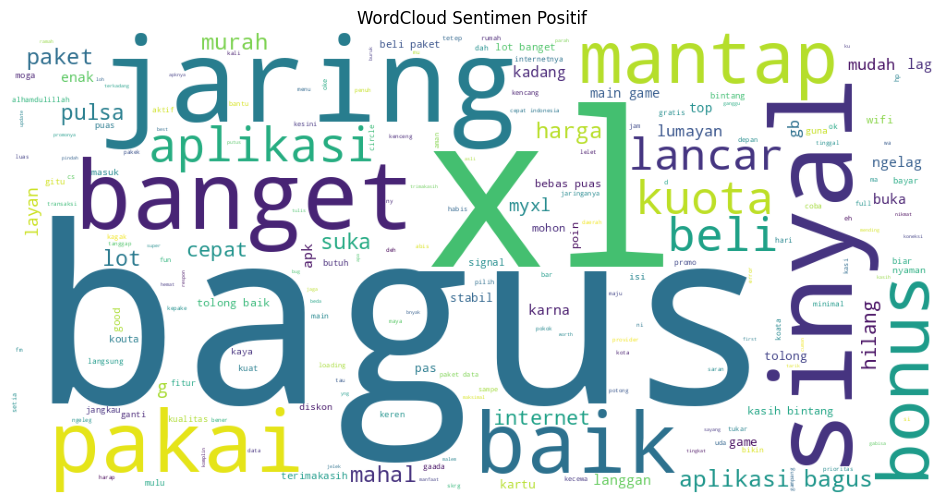

In [35]:
from wordcloud import WordCloud

positive_text = " ".join(
    df[df['sentiment']=="positive"]['stemming']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Sentimen Positif")
plt.show()

##3. WordCloud Negative

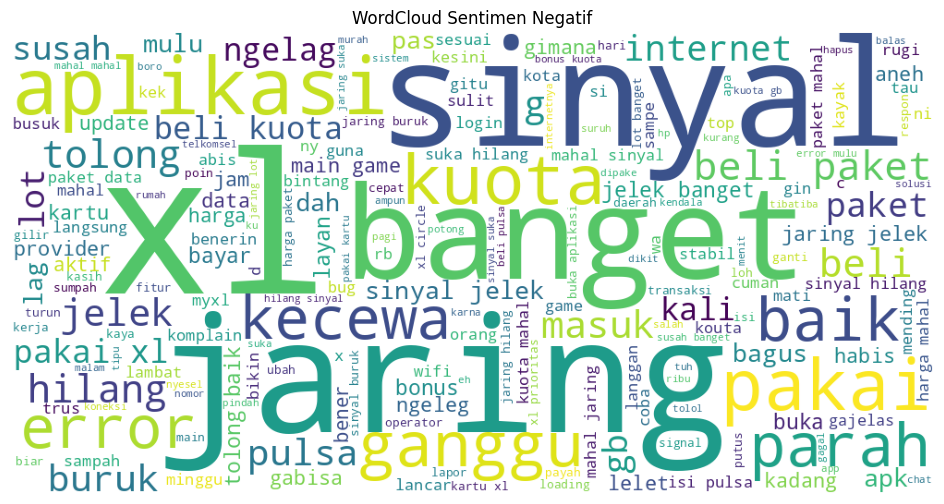

In [36]:
negative_text = " ".join(
    df[df['sentiment']=="negative"]['stemming']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Sentimen Negatif")
plt.show()

##4. Top Frequent Words

In [37]:
from collections import Counter

words = ' '.join(df['stemming']).split()

Counter(words).most_common(20)

[('xl', 1845),
 ('jaring', 1327),
 ('sinyal', 1179),
 ('paket', 900),
 ('kuota', 899),
 ('beli', 886),
 ('banget', 752),
 ('aplikasi', 691),
 ('pakai', 651),
 ('hilang', 578),
 ('jelek', 501),
 ('pulsa', 487),
 ('baik', 485),
 ('mahal', 478),
 ('tolong', 475),
 ('lot', 386),
 ('gb', 354),
 ('bagus', 345),
 ('bonus', 313),
 ('g', 311)]

In [38]:
import pandas as pd

freq = pd.DataFrame(
    Counter(words).most_common(20),
    columns=['word','count']
)

<Axes: xlabel='word'>

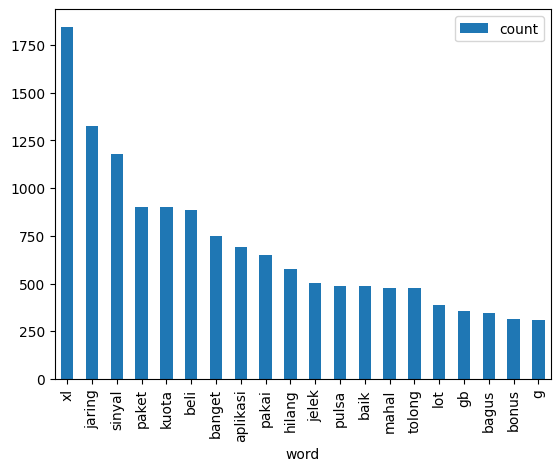

In [39]:
freq.plot.bar(
    x='word',
    y='count'
)

##5. Bigram

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    ngram_range=(2,2)
)

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(2,2))

X = cv.fit_transform(df['stemming'])

In [42]:
bigrams = cv.get_feature_names_out()

In [43]:
counts = X.sum(axis=0).A1

In [44]:
import pandas as pd

bigram_df = pd.DataFrame({
    'Bigram': bigrams,
    'Frequency': counts
})

bigram_df = bigram_df.sort_values(by='Frequency', ascending=False)

bigram_df.head(20)

,Bigram,Frequency
3029,beli paket,300
2995,beli kuota,179
24964,tolong baik,169
19076,pakai xl,166
25118,top up,152
17203,my xl,150
15403,main game,123
22874,sinyal jelek,121
19162,paket data,115
10817,jelek banget,107


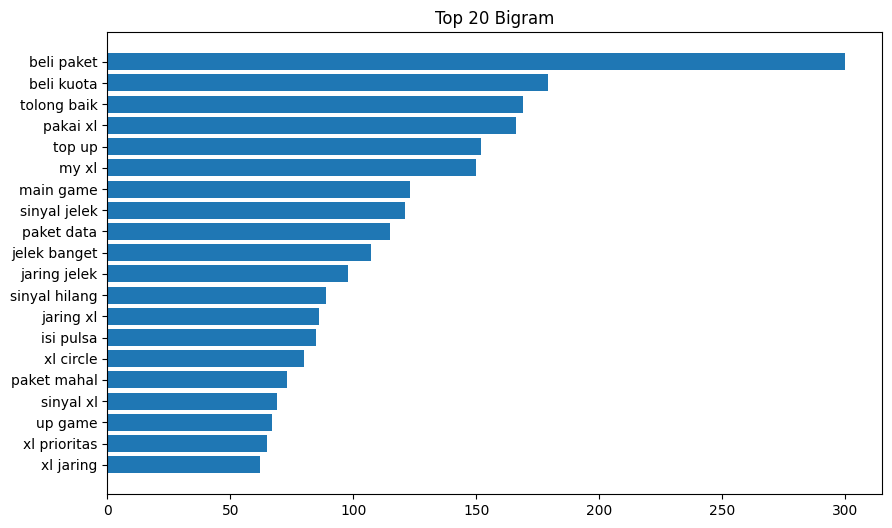

In [45]:
import matplotlib.pyplot as plt

top20 = bigram_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20['Bigram'], top20['Frequency'])
plt.gca().invert_yaxis()
plt.title("Top 20 Bigram")
plt.show()

#Feature Engineering

##Split Data

In [46]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    df['stemming'],
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)


##TF-IDF

In [47]:
df['stemming'].head()

,stemming
0,xl thun tolong sinyal baik prambanan
1,lot banget ih ganggu
2,regristrasi kartu gagal xl sampah
3,suka
4,sinyal jaring g cepat indonesia anjir jarang p...


In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)   # unigram + bigram
)

# Transformasi data teks menjadi fitur numerik
# X = tfidf.fit_transform(df['stemming'])

# Feature Engineering
X_train = tfidf.fit_transform(train_data)
X_test = tfidf.transform(test_data)

# Cek hasil
print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print(tfidf.get_feature_names_out()[:20])

Shape X_train: (3835, 5000)
Shape X_test : (959, 5000)
['aamiin' 'abai' 'abal' 'abis' 'abis beli' 'abis kuota' 'abis pakai'
 'acara' 'adain' 'adakan' 'add' 'add on' 'adu' 'aduh' 'ae' 'agen' 'agent'
 'agent response' 'ah' 'ai']


#Modeling

##Naive Bayes

In [49]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Naive Bayes
naive_bayes = MultinomialNB()

# Training model
naive_bayes.fit(X_train, train_labels)

# Prediksi data testing
# predictions = naive_bayes.predict(X_test)
pred_nb = naive_bayes.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, pred_nb)
report = classification_report(test_labels, pred_nb)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

Accuracy: 0.6861

Classification Report:
              precision    recall  f1-score   support

    negative       0.68      0.98      0.80       617
     neutral       0.74      0.19      0.30       261
    positive       1.00      0.04      0.07        81

    accuracy                           0.69       959
   macro avg       0.81      0.40      0.39       959
weighted avg       0.72      0.69      0.61       959



##Decision Tree

In [50]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, train_labels)

# predictions = decision_tree.predict(X_test)
pred_dt = decision_tree.predict(X_test)

accuracy = accuracy_score(test_labels, pred_dt)
report = classification_report(test_labels, pred_dt)

print(f'Accuracy: {accuracy}\n')
print(f'Classification Report:\n{report}')

Accuracy: 0.7340980187695516

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.82      0.81       617
     neutral       0.63      0.61      0.62       261
    positive       0.49      0.47      0.48        81

    accuracy                           0.73       959
   macro avg       0.64      0.63      0.64       959
weighted avg       0.73      0.73      0.73       959



##Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
random_forest.fit(X_train, train_labels)
# predictions = random_forest.predict(X_test)
pred_rf = random_forest.predict(X_test)
accuracy = accuracy_score(test_labels, pred_rf)
report = classification_report(test_labels, pred_rf)

print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

Accuracy: 0.7591

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.89      0.84       617
     neutral       0.68      0.54      0.60       261
    positive       0.73      0.43      0.54        81

    accuracy                           0.76       959
   macro avg       0.73      0.62      0.66       959
weighted avg       0.75      0.76      0.75       959



##AdaBoost

In [52]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost.fit(X_train, train_labels)
# predictions = adaboost.predict(X_test)
pred_adb = adaboost.predict(X_test)
accuracy = accuracy_score(test_labels, pred_adb)
report = classification_report(test_labels, pred_adb)
print(f'Accuracy: {accuracy}\n')
print(f'Classification Report:\n{classification_report(test_labels, pred_adb)}')

Accuracy: 0.6725755995828988

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      1.00      0.80       617
     neutral       0.50      0.02      0.03       261
    positive       1.00      0.31      0.47        81

    accuracy                           0.67       959
   macro avg       0.72      0.44      0.43       959
weighted avg       0.65      0.67      0.56       959



##Logistic Regresi

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Logistic Regression
logistic_regression = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Training model
logistic_regression.fit(X_train, train_labels)

# Prediksi data testing
# predictions = logistic_regression.predict(X_test)
pred_lr = logistic_regression.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, pred_lr)
report = classification_report(test_labels, pred_lr)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

Accuracy: 0.7769

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.92      0.85       617
     neutral       0.71      0.56      0.62       261
    positive       0.83      0.43      0.57        81

    accuracy                           0.78       959
   macro avg       0.78      0.63      0.68       959
weighted avg       0.77      0.78      0.76       959



##Support Vector Machine (SVM)  

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model SVM
svm = LinearSVC(random_state=42)

# Training model
svm.fit(X_train, train_labels)

# Prediksi data testing
# predictions = svm.predict(X_test)
pred_svm = svm.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, pred_svm)
report = classification_report(test_labels, pred_svm)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

##Bandingkan Model

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

In [56]:
hasil = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Logistic Regression',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(test_labels, pred_nb),
        accuracy_score(test_labels, pred_dt),
        accuracy_score(test_labels, pred_rf),
        accuracy_score(test_labels, pred_adb),
        accuracy_score(test_labels, pred_lr),
        accuracy_score(test_labels, pred_svm)
    ],
    'Precision': [
        precision_recall_fscore_support(test_labels, pred_nb, average='weighted')[0],
        precision_recall_fscore_support(test_labels, pred_dt, average='weighted')[0],
        precision_recall_fscore_support(test_labels, pred_rf, average='weighted')[0],
        precision_recall_fscore_support(test_labels, pred_adb, average='weighted')[0],
        precision_recall_fscore_support(test_labels, pred_lr, average='weighted')[0],
        precision_recall_fscore_support(test_labels, pred_svm, average='weighted')[0]
    ],
    'Recall': [
        precision_recall_fscore_support(test_labels, pred_nb, average='weighted')[1],
        precision_recall_fscore_support(test_labels, pred_dt, average='weighted')[1],
        precision_recall_fscore_support(test_labels, pred_rf, average='weighted')[1],
        precision_recall_fscore_support(test_labels, pred_adb, average='weighted')[1],
        precision_recall_fscore_support(test_labels, pred_lr, average='weighted')[1],
        precision_recall_fscore_support(test_labels, pred_svm, average='weighted')[1]
    ],
    'F1-Score': [
        precision_recall_fscore_support(test_labels, pred_nb, average='weighted')[2],
        precision_recall_fscore_support(test_labels, pred_dt, average='weighted')[2],
        precision_recall_fscore_support(test_labels, pred_rf, average='weighted')[2],
        precision_recall_fscore_support(test_labels, pred_adb, average='weighted')[2],
        precision_recall_fscore_support(test_labels, pred_lr, average='weighted')[2],
        precision_recall_fscore_support(test_labels, pred_svm, average='weighted')[2]
    ]
})

hasil = hasil.sort_values(by='Accuracy', ascending=False)
hasil.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
5,SVM,0.7873,0.7816,0.7873,0.7824
4,Logistic Regression,0.7769,0.7737,0.7769,0.7644
2,Random Forest,0.7591,0.7515,0.7591,0.7478
1,Decision Tree,0.7341,0.7311,0.7341,0.7325
0,Naive Bayes,0.6861,0.7229,0.6861,0.6060
3,AdaBoost,0.6726,0.6485,0.6726,0.5616


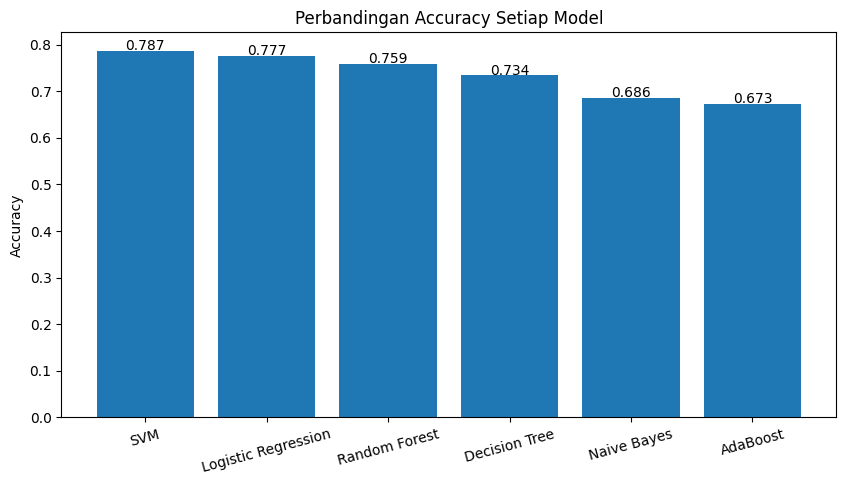

In [57]:
plt.figure(figsize=(10,5))

plt.bar(hasil['Model'], hasil['Accuracy'])

plt.title("Perbandingan Accuracy Setiap Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

for i, v in enumerate(hasil['Accuracy']):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()

#Model Evaluation

Accuracy: 0.7873

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.88      0.85       617
     neutral       0.71      0.63      0.67       261
    positive       0.70      0.56      0.62        81

    accuracy                           0.79       959
   macro avg       0.74      0.69      0.71       959
weighted avg       0.78      0.79      0.78       959



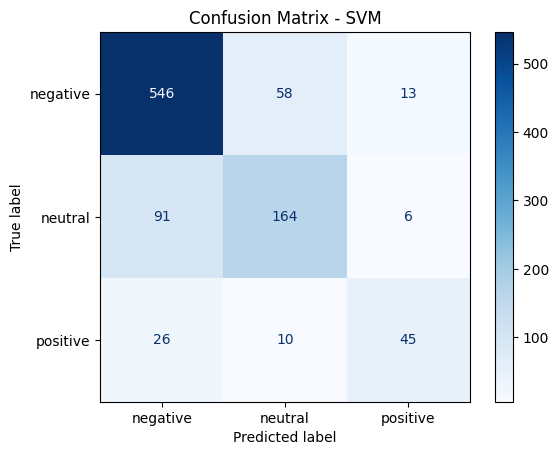

In [58]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Prediksi SVM
pred_svm = svm.predict(X_test)

# Accuracy
accuracy = accuracy_score(test_labels, pred_svm)
print(f"Accuracy: {accuracy:.4f}\n")

# Precision, Recall, F1-score
print("Classification Report:")
print(classification_report(test_labels, pred_svm))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    test_labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - SVM")
plt.show()

In [63]:
#cek tipe apa (pikun)
print(type(svm))
print(svm)

<class 'sklearn.svm._classes.LinearSVC'>
LinearSVC(random_state=42)


#Probability Calibration

##Calibrated LinearSVC

In [64]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

# Model dasar LinearSVC
base_svm = LinearSVC(random_state=42)

# Kalibrasi probabilitas dengan cross-validation
calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method='sigmoid',
    cv=5
)

# Training model terkalibrasi
calibrated_svm.fit(X_train, train_labels)

CalibratedClassifierCV(cv=5, estimator=LinearSVC(random_state=42))

##Evaluation After Calibration

Accuracy Calibrated SVM: 0.7852

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.90      0.85       617
     neutral       0.72      0.58      0.65       261
    positive       0.76      0.54      0.63        81

    accuracy                           0.79       959
   macro avg       0.76      0.68      0.71       959
weighted avg       0.78      0.79      0.78       959



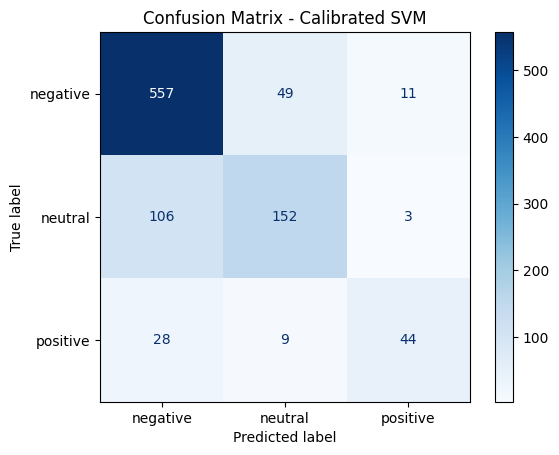

In [65]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Prediksi menggunakan Calibrated SVM
pred_calibrated = calibrated_svm.predict(X_test)

# Accuracy
accuracy_calibrated = accuracy_score(
    test_labels,
    pred_calibrated
)

print(f"Accuracy Calibrated SVM: {accuracy_calibrated:.4f}\n")

# Precision, Recall, F1-Score, dan Support
print("Classification Report:")
print(
    classification_report(
        test_labels,
        pred_calibrated
    )
)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    calibrated_svm,
    X_test,
    test_labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - Calibrated SVM")
plt.show()

##Probability Check

In [66]:
# Cek probabilitas hasil kalibrasi
probabilities = calibrated_svm.predict_proba(X_test[:5])

print("Classes:")
print(calibrated_svm.classes_)

print("\nProbabilities:")
print(probabilities)

Classes:
['negative' 'neutral' 'positive']

Probabilities:
[[0.42366873 0.39188466 0.18444661]
 [0.53799315 0.40456941 0.05743744]
 [0.79117024 0.17499477 0.03383499]
 [0.48524351 0.47986414 0.03489235]
 [0.52317834 0.4651186  0.01170307]]


#Deploy

##NonKalibrasi

In [59]:
# import joblib
# joblib.dump(svm, 'svm_model.pkl')

['svm_model.pkl']

In [60]:
# joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

In [61]:
# #cek file
# import os

# os.listdir()

['.config', 'tfidf.pkl', 'svm_model.pkl', 'sample_data']

##Kalibrasi

In [67]:
import joblib

# Simpan model SVM yang sudah dikalibrasi
joblib.dump(
    calibrated_svm,
    'svm_calibrated_model.pkl'
)

# Simpan TF-IDF Vectorizer
joblib.dump(
    tfidf,
    'tfidf.pkl'
)

print("Model dan TF-IDF berhasil disimpan.")

Model dan TF-IDF berhasil disimpan.


In [68]:
import os

print(os.listdir())

['.config', 'tfidf.pkl', 'svm_model.pkl', 'svm_calibrated_model.pkl', 'sample_data']
